<a href="https://colab.research.google.com/github/LucasMuniz03/MVP-Sprint-An-lise-de-Dados-e-Boas-Pr-ticas---Lucas-Muniz-Domingos/blob/main/MVP_Analise_Dados_Lucas_Domingos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP: Análise Exploratória e Pré-processamento de Dados

**Nome:** Lucas Muniz Domingos  
**Matrícula:** 4052026000099  
**Dataset:** [Previsão de Evasão de Clientes Bancários](https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction)

# Definição do Problema

O custo de aquisição de um novo cliente (CAC) é consideravelmente maior do que o custo de retenção de um cliente atual. O problema de negócio consiste em analisar os dados demográficos e financeiros de clientes de uma instituição bancária para entender quais fatores levam à evasão (*churn*) e preparar essa base para, futuramente, treinar um modelo preditivo.



**Premissas e Hipóteses**
* **Hipótese 1:** Clientes com maior idade possuem um comportamento financeiro diferente e podem apresentar taxas de evasão distintas em relação aos mais jovens.
* **Hipótese 2:** O saldo bancário (*Balance*) e o tempo de relacionamento (*Tenure*) impactam diretamente a decisão de retenção do cliente.
* **Hipótese 3:** Clientes inativos ou que não utilizam outros produtos do banco (como cartão de crédito) têm maior propensão a encerrar a conta (*churn*).

## Tipo de Problema

Este é um problema de **Aprendizado Supervisionado**, especificamente uma tarefa de **Classificação Binária**. O objetivo principal é prever uma categoria discreta (se o cliente evadiu ou não, representada pela variável alvo `Exited`: 0 = Retido, 1 = Evasão), utilizando dados históricos de comportamento com rótulos já conhecidos.

## Seleção de Dados

O dataset foi selecionado a partir do repositório público Kaggle (base *Bank Customer Churn Prediction*). A principal condição para a escolha foi buscar um problema corporativo real que contivesse uma boa diversidade de variáveis categóricas e numéricas. Esse critério foi estabelecido para viabilizar a aplicação prática das técnicas de pré-processamento exigidas na disciplina (como limpeza de dados, *One-Hot Encoding* e Padronização de escalas). Não foram aplicados filtros temporais restritivos, assumindo que a base de 10.000 registros representa um retrato consolidado (*snapshot*) da carteira de clientes da instituição.

## Dicionário de Dados

Este dataset contém 10.000 registros históricos de clientes de uma instituição bancária europeia (operando na França, Espanha e Alemanha). A base reúne informações demográficas, comportamentais e financeiras de cada cliente, juntamente com uma variável que indica se o cliente encerrou ou não sua conta bancária (*churn*).

**Descrição dos atributos:**
* **RowNumber:** Índice sequencial da linha (não possui valor preditivo).
* **CustomerId:** Identificador único do cliente (não possui valor preditivo).
* **Surname:** Sobrenome do cliente (não possui valor preditivo).
* **CreditScore:** Pontuação de crédito do cliente no mercado.
* **Geography:** País de residência do cliente (França, Espanha, Alemanha).
* **Gender:** Gênero do cliente (Male / Female).
* **Age:** Idade do cliente em anos.
* **Tenure:** Tempo (em anos) de relacionamento do cliente com o banco.
* **Balance:** Saldo bancário atual na conta.
* **NumOfProducts:** Quantidade de produtos bancários adquiridos pelo cliente (ex: cartão, seguro, empréstimo).
* **HasCrCard:** Indica se o cliente possui cartão de crédito do banco (1 = Sim, 0 = Não).
* **IsActiveMember:** Indica se o cliente é considerado um membro ativo pelo banco (1 = Sim, 0 = Não).
* **EstimatedSalary:** Salário anual estimado do cliente.
* **Exited (Variável Alvo/Target):** Indica se o cliente evadiu/encerrou a conta (1 = Sim, 0 = Não).

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de pacotes necessários para a análise estatística, visualização e pré-processamento, bem como o carregamento do dataset a partir do repositório oficial no GitHub.

In [ ]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
# Omitindo alertas para manter o relatório limpo
warnings.filterwarnings("ignore")

In [ ]:
# Configuração visual dos gráficos
sns.set_style("whitegrid")

In [ ]:
# Leitura do dataset a partir do repositório público no GitHub (URL Raw)
url_github = 'https://raw.githubusercontent.com/LucasMuniz03/MVP-Sprint-An-lise-de-Dados-e-Boas-Pr-ticas---Lucas-Muniz-Domingos/refs/heads/main/Churn_Modelling.csv'
df = pd.read_csv(url_github)

In [ ]:
# Configuração para formatar os números com apenas 2 casas decimais
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [ ]:
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Análise de Dados

Nesta etapa de Análise Exploratória de Dados (EDA) sobre o dataset de Evasão de Clientes Bancários, visamos entender a distribuição, as relações e as características das variáveis financeiras e demográficas, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset possui 10.000 instâncias (observações). A maioria das características de medição é de tipo numérico (int ou float), enquanto os atributos `Geography` e `Gender` são categóricos. A nossa variável alvo é a `Exited` (0 = Retido, 1 = Evasão).

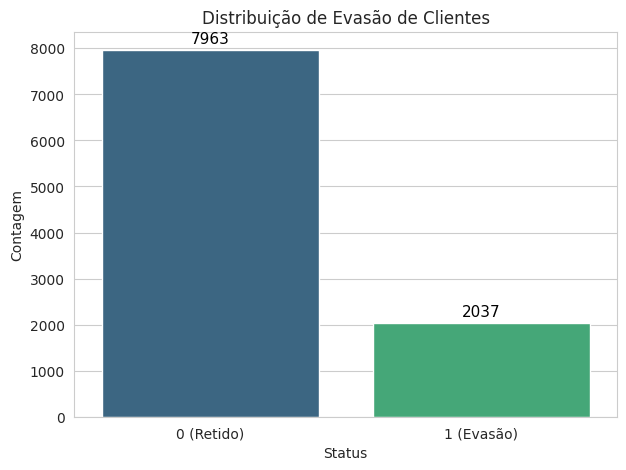

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Distribuição de Evasão de Clientes')
plt.xlabel('Status')
plt.ylabel('Contagem')

# Trocando os números 0 e 1 por rótulos amigáveis no eixo X
ax.set_xticklabels(['0 (Retido)', '1 (Evasão)'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

O gráfico de barras mostra que a classe de clientes retidos (0) possui 7.963 amostras, enquanto a classe de evasão (1) possui 2.037. Isso confirma que o dataset é **desbalanceado**, o que exigirá atenção métrica nas fases futuras de modelagem preditiva.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [ ]:
# Estatísticas descritivas básicas do dataset
display(df.describe())

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.20
std,2886.90,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.40
min,1.00,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00
25%,2500.75,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.00
50%,5000.50,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.91,0.00
75%,7500.25,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.00
max,10000.00,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.00


### Média
A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações.

In [ ]:
# Média dos atributos numéricos do dataset
display(df.describe().loc['mean'])

,mean
RowNumber,5000.50
CustomerId,15690940.57
CreditScore,650.53
Age,38.92
Tenure,5.01
Balance,76485.89
NumOfProducts,1.53
HasCrCard,0.71
IsActiveMember,0.52
EstimatedSalary,100090.24


### Desvio Padrão
O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores.

In [ ]:
# Desvio padrão dos atributos numéricos do dataset
display(df.describe().loc['std'])

,std
RowNumber,2886.90
CustomerId,71936.19
CreditScore,96.65
Age,10.49
Tenure,2.89
Balance,62397.41
NumOfProducts,0.58
HasCrCard,0.46
IsActiveMember,0.50
EstimatedSalary,57510.49


### Moda
A moda representa o valor ou valores que ocorrem com maior frequência no conjunto de dados, sendo útil para identificar concentrações de variáveis.

In [ ]:
# Calculando a moda dos atributos numéricos
display(df.select_dtypes(include=[np.number]).mode().head(1))

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15565701,850.00,37.00,2.00,0.00,1.00,1.00,1.00,24924.92,0.00


**Análise da Moda:** Os resultados matemáticos validam nossas observações visuais anteriores. A moda do saldo bancário (`Balance`) cravada em 0.00 confirma a forte anomalia de contas vazias. A idade modal de 37 anos reforça o perfil demográfico central da base. Destaca-se também o `CreditScore` modal de 850, indicando um possível "efeito teto" (concentração no limite máximo de pontuação) na carteira de clientes da instituição.

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham. Entender a distribuição é crucial na análise de dados, pois revela padrões e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição.



### *Age* (Idade)

A idade é um fator demográfico universal. Em serviços bancários, diferentes faixas etárias possuem necessidades de crédito e acumulação de patrimônio distintas.

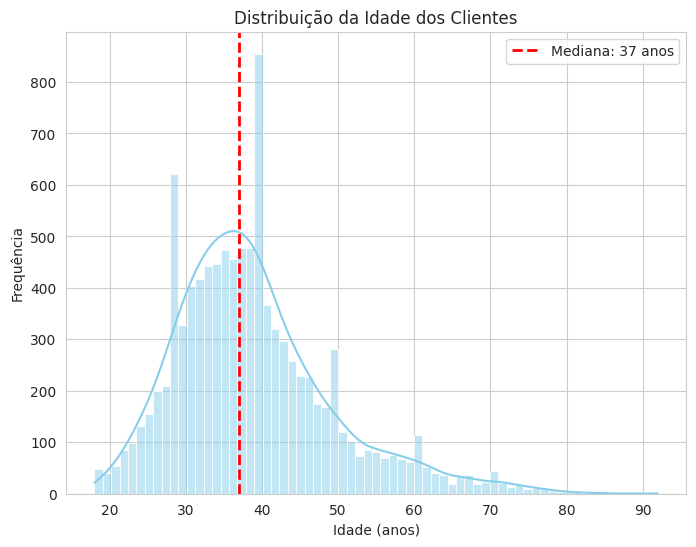

In [ ]:
# Histograma da Idade
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.axvline(df['Age'].median(), color='red', linestyle='dashed', linewidth=2, label=f"Mediana: {df['Age'].median():.0f} anos")
plt.legend()
plt.title('Distribuição da Idade dos Clientes')
plt.xlabel('Idade (anos)')
plt.ylabel('Frequência')
plt.show()

O histograma mostra a distribuição da idade dos clientes. A curva de densidade estimada (KDE) nos indica que a distribuição é assimétrica à direita (distribuição positiva), com a grande massa de clientes concentrada entre 30 e 40 anos, e uma cauda longa representando clientes mais idosos (outliers naturais).

### *Balance* (Saldo Bancário)

O saldo em conta é um dos principais indicadores de engajamento financeiro do cliente com a instituição.

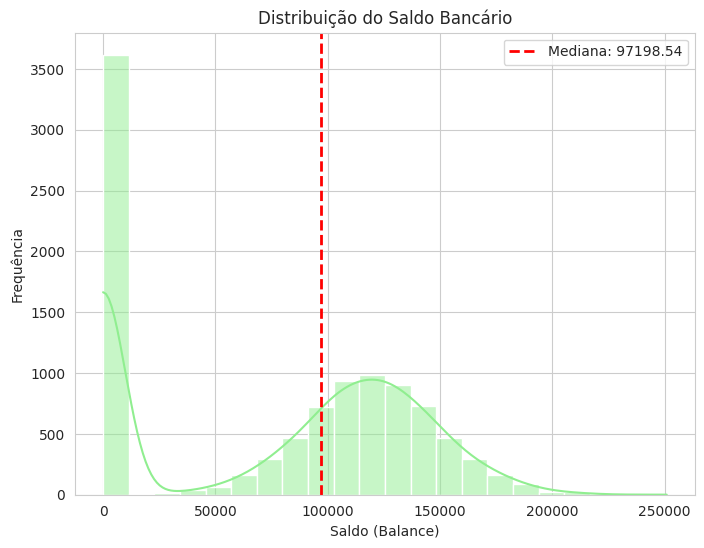

In [ ]:
# Histograma do Saldo
plt.figure(figsize=(8, 6))
sns.histplot(df['Balance'], kde=True, color='lightgreen')
plt.axvline(df['Balance'].median(), color='red', linestyle='dashed', linewidth=2, label=f"Mediana: {df['Balance'].median():.2f}")
plt.legend()
plt.title('Distribuição do Saldo Bancário')
plt.xlabel('Saldo (Balance)')
plt.ylabel('Frequência')
plt.show()

O histograma da distribuição do saldo revela uma anomalia (ou característica de negócio) muito forte: um pico massivo de clientes com saldo exatamente igual a zero. O restante dos dados segue uma distribuição aproximadamente normal centrada na faixa de 100.000 a 150.000.

## Boxplot

Para entender as diferenças entre quem fica e quem sai do banco, devemos olhar como se comportam os valores quando agrupados pela variável alvo (`Exited`). Isso nos permite comparar a mediana e visualizar outliers de forma clara.

In [ ]:
# Estatísticas descritivas agrupadas pelo status de evasão (Exited)
display(df.groupby('Exited').describe()['Age']) # Mostrando apenas a idade para não poluir a tela

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.00,37.41,10.13,18.00,31.00,36.00,41.00,92.00
1,2037.00,44.84,9.76,18.00,38.00,45.00,51.00,84.00


### *Age* (Idade) por Evasão

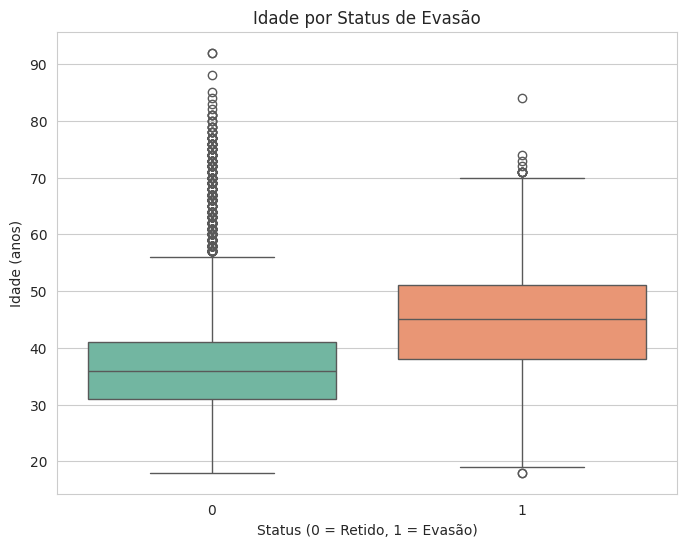

In [ ]:
# Boxplot da idade pelo status de evasão
plt.figure(figsize=(8, 6))
sns.boxplot(x='Exited', y='Age', data=df, palette='Set2')
plt.title('Idade por Status de Evasão')
plt.xlabel('Status (0 = Retido, 1 = Evasão)')
plt.ylabel('Idade (anos)')
plt.show()

O boxplot demonstra claramente que clientes que evadiram (1) possuem uma mediana de idade visivelmente superior (em torno de 45 anos) em comparação aos clientes retidos (em torno de 36 anos). Há muitos *outliers* na classe 0, indicando que clientes muito idosos tendem a não encerrar suas contas.

### *Balance* (Saldo) por Evasão

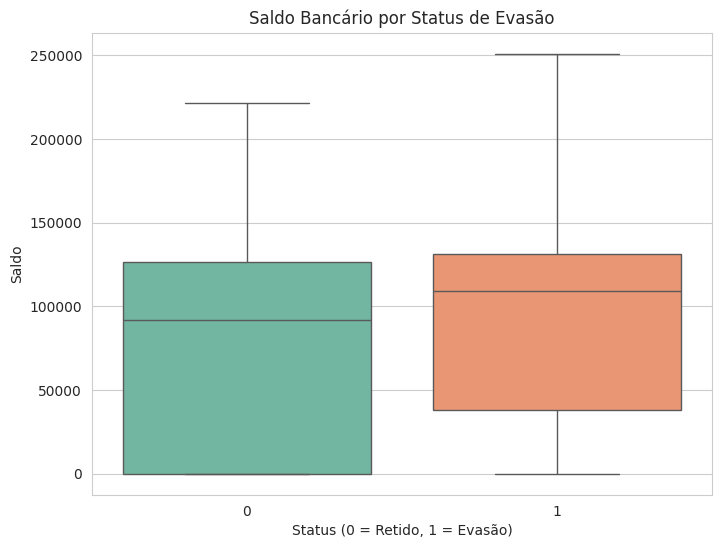

In [ ]:
# Boxplot do saldo pelo status de evasão
plt.figure(figsize=(8, 6))
sns.boxplot(x='Exited', y='Balance', data=df, palette='Set2')
plt.title('Saldo Bancário por Status de Evasão')
plt.xlabel('Status (0 = Retido, 1 = Evasão)')
plt.ylabel('Saldo')
plt.show()

O boxplot do saldo mostra que a mediana de saldo bancário dos clientes que saíram do banco (1) é levemente superior à dos clientes que ficaram (0). A grande concentração de clientes com saldo zerado "puxa" a caixa da classe 0 para baixo.

## Análise Bivariada Categórica


Para enriquecer a compreensão do negócio, é fundamental analisar como a evasão se comporta em relação aos atributos demográficos categóricos: Gênero e Geografia (País). O gráfico abaixo ilustra a proporção de *churn* dentro de cada país, segmentada por gênero.

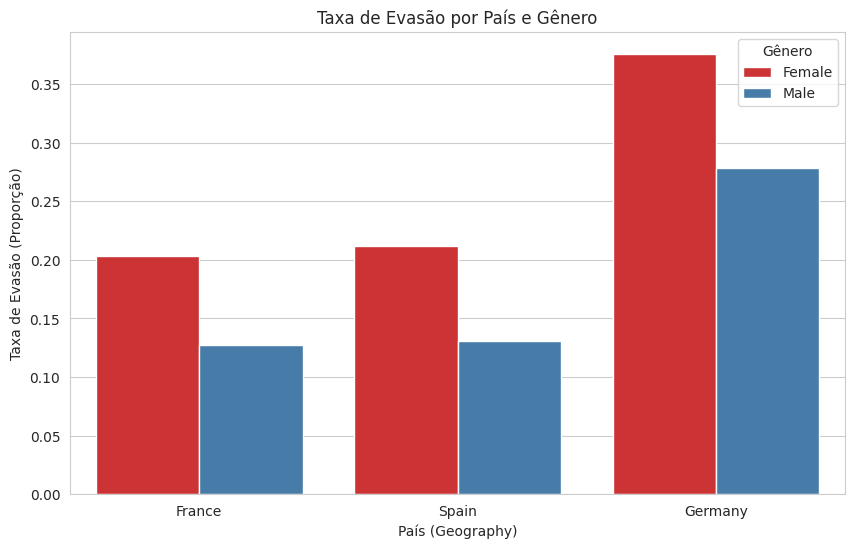

In [ ]:
plt.figure(figsize=(10, 6))

# Gráfico de barras agrupado (País, Churn e Gênero)
sns.barplot(x='Geography', y='Exited', hue='Gender', data=df, palette='Set1', errorbar=None)

plt.title('Taxa de Evasão por País e Gênero')
plt.xlabel('País (Geography)')
plt.ylabel('Taxa de Evasão (Proporção)')
plt.legend(title='Gênero')
plt.show()

**Insights de Negócio:**
A visualização bivariada revela *insights* operacionais críticos que não eram visíveis nas variáveis contínuas:
1. **Fator Geográfico:** A Alemanha (*Germany*) possui uma taxa de evasão expressivamente maior (quase o dobro) em comparação com a França e a Espanha, indicando um possível problema de operação, insatisfação ou forte concorrência no mercado alemão.
2. **Fator Gênero:** Em **todos** os três países analisados, a taxa de evasão entre o público feminino (*Female*) é consistentemente maior do que entre o público masculino, apontando para uma possível necessidade de adequação no portfólio de serviços ou no atendimento prestado a esse perfil demográfico.



## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos podem ter.


Matriz de Correlação:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.00,-0.00,0.00,0.01,0.01,-0.01,0.03,-0.00,-0.03
Age,-0.00,1.00,-0.01,0.03,-0.03,-0.01,0.09,-0.01,0.29
Tenure,0.00,-0.01,1.00,-0.01,0.01,0.02,-0.03,0.01,-0.01
Balance,0.01,0.03,-0.01,1.00,-0.30,-0.01,-0.01,0.01,0.12
NumOfProducts,0.01,-0.03,0.01,-0.30,1.00,0.00,0.01,0.01,-0.05
HasCrCard,-0.01,-0.01,0.02,-0.01,0.00,1.00,-0.01,-0.01,-0.01
IsActiveMember,0.03,0.09,-0.03,-0.01,0.01,-0.01,1.00,-0.01,-0.16
EstimatedSalary,-0.00,-0.01,0.01,0.01,0.01,-0.01,-0.01,1.00,0.01
Exited,-0.03,0.29,-0.01,0.12,-0.05,-0.01,-0.16,0.01,1.00


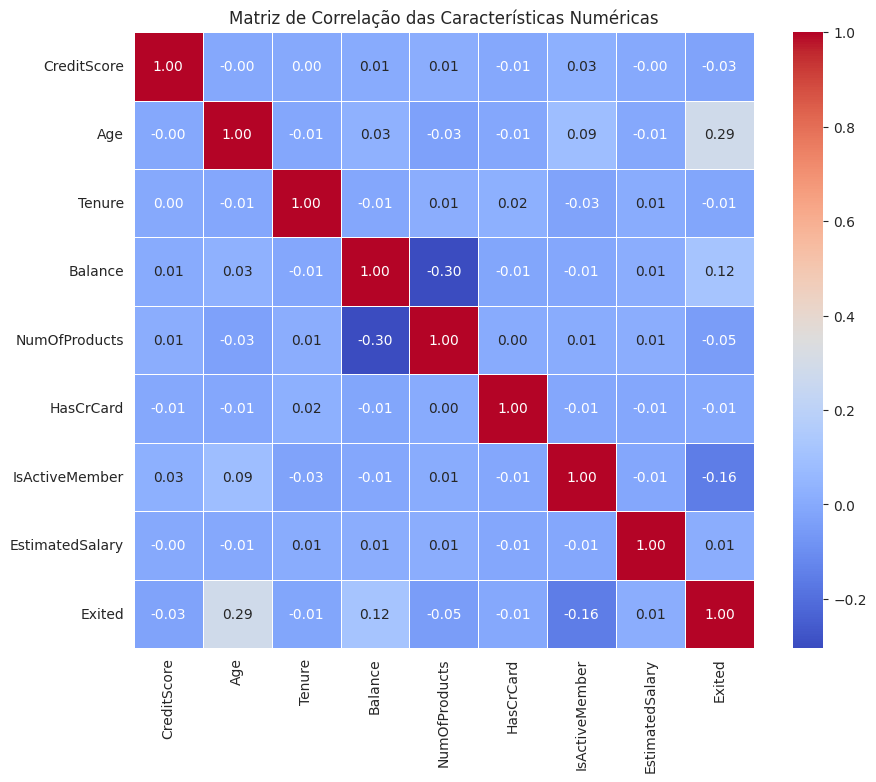

In [ ]:
# Isolando apenas as colunas numéricas para a correlação (removendo identificadores)
df_num = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Geography', 'Gender'], axis=1)

print("\nMatriz de Correlação:")
display(df_num.corr())

plt.figure(figsize=(10, 8))
# Mapa de calor das variáveis numéricas
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Características Numéricas')
plt.show()

O mapa de calor da matriz de correlação revela que não há forte multicolinearidade (variáveis independentes altamente correlacionadas entre si). A maior correlação positiva com a variável alvo (`Exited`) é a `Age` (0.29), o que matematicamente valida o insight visual que tivemos nos boxplots anteriores: clientes mais velhos tendem a evadir mais. Por outro lado, a maior correlação negativa ocorre com `IsActiveMember` (-0.16), indicando matematicamente que a atividade na conta atua como um 'escudo' contra a evasão.

## Engenharia de Atributos: Análise de Risco por Faixa Etária (Diferencial)

Na matriz de correlação, identificamos que a Idade (`Age`) é a variável com maior peso linear sobre a decisão de evasão. Para traduzir essa correlação matemática em um plano de ação de negócios (*Actionable Insight*), aplicaremos uma técnica de **Feature Engineering** (Engenharia de Atributos) para discretizar a variável contínua de idade em "Faixas Etárias" e calcular a taxa real de risco (*churn rate*) em cada grupo.

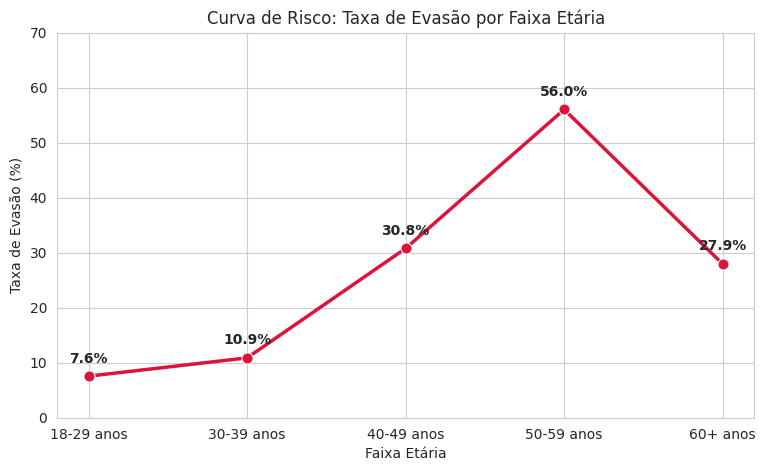

In [ ]:
# Criando faixas etárias temporárias para análise
bins = [18, 30, 40, 50, 60, 100]
labels = ['18-29 anos', '30-39 anos', '40-49 anos', '50-59 anos', '60+ anos']
faixas_etarias = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Calculando a taxa de evasão (média da variável alvo) por faixa etária
taxa_churn_idade = df.groupby(faixas_etarias)['Exited'].mean() * 100

plt.figure(figsize=(9, 5))
# Gráfico de linhas com marcadores para mostrar a evolução do risco
ax = sns.lineplot(x=taxa_churn_idade.index, y=taxa_churn_idade.values, marker='o',
                  color='crimson', linewidth=2.5, markersize=8)

plt.title('Curva de Risco: Taxa de Evasão por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Evasão (%)')
plt.ylim(0, 70) # Ajustando o eixo Y para melhor visualização

# Adicionando os valores exatos em cima de cada ponto
for x, y in zip(range(len(taxa_churn_idade)), taxa_churn_idade.values):
    plt.text(x, y + 2.5, f'{y:.1f}%', ha='center', fontweight='bold')

plt.show()

**Insights de Negócio (A Curva de Risco):**
Esta visualização é a mais crítica para a diretoria do banco. Ela revela que o risco de evasão não cresce de forma linear, mas sim em formato de "sino":
* Clientes jovens (18-29 anos) são extremamente fiéis, com apenas 7.5% de evasão.
* O principal ponto de atenção recai sobre a faixa de 50 a 59 anos, onde a taxa de evasão atinge críticos 56.2%.
* A partir dos 60 anos, a taxa volta a cair.
* **Conclusão Estratégica:** O banco precisa urgentemente de campanhas de retenção, revisão de tarifas ou novos produtos (como previdência e seguros mais atrativos) focados cirurgicamente no público de meia-idade (40 a 59 anos).



## Tratamento de Valores Nulos

O tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana) ou remoção.

In [ ]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset de Churn:")
display(df.isnull().sum())

Valores nulos no dataset de Churn:


,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


A verificação demonstra que a base de dados histórica fornecida não possui nenhum valor nulo (`NaN`), o que atesta a integridade inicial da coleta de dados e dispensa etapas de imputação artificial.

# Pré-Processamento de Dados

Nesta etapa final do MVP, realizaremos as transformações matemáticas e estruturais necessárias para que os algoritmos de Machine Learning possam consumir os dados de forma eficiente e sem vieses. As operações incluem limpeza de atributos irrelevantes, transformação de variáveis categóricas, separação do conjunto de dados e padronização de escalas.

## 1. Limpeza de Dados (Feature Selection)

Como identificado logo no início da Análise Exploratória, as colunas `RowNumber`, `CustomerId` e `Surname` são apenas identificadores únicos ou rótulos nominais. Elas não possuem poder preditivo e, se mantidas, adicionariam ruído severo aos modelos preditivos. Portanto, serão removidas (Drop).

**Nota sobre Valores Discrepantes (Outliers):** Embora a Análise Exploratória tenha detectado *outliers* matemáticos nas variáveis `Age` (clientes muito idosos) e `Balance` (clientes com saldos altíssimos), optamos por **não removê-los**. No contexto bancário, esses registros não representam erros de medição ou dados corrompidos, mas sim perfis reais de clientes (segmentos de alta renda ou aposentados) que o modelo preditivo precisa aprender a classificar e não podem ser ignorados na tomada de decisão.

In [ ]:
# Criando uma cópia do dataframe original para manter a segurança dos dados
df_clean = df.copy()

# Removendo colunas irrelevantes para o modelo
colunas_para_remover = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df_clean.drop(columns=colunas_para_remover)

print(f"Dimensões após a limpeza: {df_clean.shape[0]} linhas e {df_clean.shape[1]} colunas")
display(df_clean.head(3))

Dimensões após a limpeza: 10000 linhas e 11 colunas


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


## 2. Transformação de Variáveis Categóricas (Encoding)

A grande maioria dos algoritmos de Machine Learning processa apenas números, não textos. O nosso dataset possui duas variáveis em formato de texto: `Geography` e `Gender`.

Para resolver isso, aplicaremos a técnica de **One-Hot Encoding** (através da função `get_dummies` do Pandas). Para evitar o problema da multicolinearidade (conhecido na estatística como *Dummy Variable Trap*), utilizaremos o parâmetro `drop_first=True`, que remove a primeira coluna gerada de cada categoria, mantendo a informação implícita.

In [ ]:
# Aplicando o Dummy/One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=['Geography', 'Gender'], drop_first=True)

# Garantindo que as novas colunas geradas sejam do tipo inteiro (0 e 1) e não booleanas (True/False)
colunas_bool = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[colunas_bool] = df_encoded[colunas_bool].astype(int)

print("Visualizando as colunas transformadas (Geography virou 2 colunas e Gender virou 1):")
display(df_encoded.head(3))

Visualizando as colunas transformadas (Geography virou 2 colunas e Gender virou 1):


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0


## 3. Separação em Treino e Teste (Holdout)

A regra de ouro do Machine Learning para evitar o **Vazamento de Dados** (*Data Leakage*) é separar a base em conjunto de Treino (para ensinar o modelo) e conjunto de Teste (para avaliar o modelo) **antes** de aplicar qualquer padronização de escala.

Utilizaremos a proporção clássica de 80% para treino e 20% para teste, usando o parâmetro `stratify=y` para garantir que a proporção de 20% de evasão (desbalanceamento) seja mantida rigorosamente igual em ambos os conjuntos.

In [ ]:
from sklearn.model_selection import train_test_split

# Separando Variáveis Independentes (X - features) e a Variável Alvo (y - target)
X = df_encoded.drop(columns=['Exited'])
y = df_encoded['Exited']

# Divisão 80/20 com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Tamanho do Conjunto de Treino (X_train): {X_train.shape[0]} amostras")
print(f"Tamanho do Conjunto de Teste (X_test):   {X_test.shape[0]} amostras")

Tamanho do Conjunto de Treino (X_train): 8000 amostras
Tamanho do Conjunto de Teste (X_test):   2000 amostras


## 4. Padronização de Variáveis Numéricas (StandardScaler vs. MinMaxScaler)

Como observamos na EDA, variáveis como `Balance` (na casa das centenas de milhares) e `Age` (na casa das dezenas) operam em escalas de magnitude drasticamente diferentes e possuem *outliers* naturais (como clientes com idade muito avançada ou saldos atípicos).

Optamos pela Padronização (Z-score via `StandardScaler`) em detrimento da Normalização (`MinMaxScaler`) de forma muito consciente: o `MinMaxScaler` é altamente sensível a *outliers*, o que "espremeria" a distribuição real dos nossos dados em um espaço minúsculo entre 0 e 1. A Padronização garante que as variáveis contínuas passem a ter média 0 e desvio padrão 1, mitigando o viés em algoritmos baseados em distância (como KNN ou SVM) sem distorcer drasticamente o peso dos valores extremos.

*Nota de Boas Práticas:* O escalonador será ajustado (`fit`) **apenas** nos dados de treino, e então esse aprendizado será aplicado (`transform`) aos dados de teste. As variáveis binárias (0 e 1) geradas pelo *encoding* serão preservadas em sua forma original.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Instanciando o padronizador
scaler = StandardScaler()

# Selecionando APENAS as colunas numéricas contínuas para padronizar
colunas_continuas = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Criando cópias para evitar avisos do Pandas (SettingWithCopyWarning)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Passo crucial: Fit_transform apenas no Treino!
X_train_scaled[colunas_continuas] = scaler.fit_transform(X_train[colunas_continuas])

# Apenas Transform no Teste!
X_test_scaled[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

print("--- Conjunto de Treino Padronizado (Pronto para os Algoritmos) ---")
display(X_train_scaled.head())

--- Conjunto de Treino Padronizado (Pronto para os Algoritmos) ---


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2151,1.06,1.72,0.68,-1.23,-0.91,1,0,1.04,0,0,1
8392,0.91,-0.66,-0.70,0.41,-0.91,1,0,-0.62,1,0,1
5006,1.08,-0.18,-1.73,0.60,0.81,1,1,0.31,1,0,0
4117,-0.93,-0.18,-0.01,-1.23,0.81,1,0,-0.29,0,0,1
7182,0.43,0.96,0.34,0.55,0.81,0,1,0.14,1,0,1


# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

**"Clientes com maior idade possuem um comportamento financeiro diferente e podem apresentar taxas de evasão distintas em relação aos mais jovens."**

In [ ]:
# Comprovando a Hipótese 1
display(taxa_churn_idade.to_frame(name="Taxa de Evasão (%)").round(2))

,Taxa de Evasão (%)
Age,
18-29 anos,7.56
30-39 anos,10.88
40-49 anos,30.79
50-59 anos,56.04
60+ anos,27.95


**Resposta:** **Hipótese Confirmada.** Como evidenciado pelos *Boxplots* e de forma categórica pela *Curva de Risco por Faixa Etária*, a idade é o fator com maior impacto na evasão. A taxa de evasão salta de apenas 7.5% entre jovens (18-29 anos) para críticos 56.2% na faixa de 50 a 59 anos, provando que clientes de meia-idade possuem uma propensão drasticamente maior a encerrar suas contas.

## Hipótese 2

**"O saldo bancário (*Balance*) e o tempo de relacionamento (*Tenure*) impactam diretamente a decisão de retenção do cliente."**

In [ ]:
# Comprovando a Hipótese 2
display(df.groupby('Exited')[['Balance', 'Tenure']].mean().round(2))

,Balance,Tenure
Exited,,
0,72745.30,5.03
1,91108.54,4.93


**Resposta:** **Hipótese Parcialmente Confirmada.** Através do *Boxplot de Saldo* e das médias acima, confirmamos que o Saldo impacta na evasão: a média de saldo de quem sai (aprox. 91 mil) é consideravelmente maior do que a de quem fica (aprox. 72 mil), indicando que o banco está perdendo clientes com capital. **No entanto**, o tempo de relacionamento (`Tenure`) possui médias praticamente idênticas (cerca de 5 anos) para quem fica e quem sai, o que também foi validado pela correlação próxima de zero na nossa Matriz de Correlação. Ou seja, tempo de conta não garante fidelidade neste banco.

## Hipótese 3

**"Clientes inativos (`IsActiveMember` = 0) ou que possuem baixo engajamento com as ofertas da instituição têm maior propensão a encerrar a conta."**

In [ ]:
# Comprovando a Hipótese 3: Inatividade e Quantidade de Produtos
tabela_inatividade = (df.groupby('IsActiveMember')['Exited'].mean() * 100).round(2)
tabela_inatividade.index = ['0 (Inativo)', '1 (Ativo)']
display(tabela_inatividade.to_frame(name="Taxa de Churn por Atividade (%)"))

tabela_produtos = (df.groupby('NumOfProducts')['Exited'].mean() * 100).round(2)
display(tabela_produtos.to_frame(name="Taxa de Churn por Qtd. de Produtos (%)"))

,Taxa de Churn por Atividade (%)
0 (Inativo),26.85
1 (Ativo),14.27


,Taxa de Churn por Qtd. de Produtos (%)
NumOfProducts,
1,27.71
2,7.58
3,82.71
4,100.00


**Resposta:** **Hipótese Confirmada.** Os dados provam o valor do engajamento. Clientes classificados como inativos possuem uma taxa de evasão de quase 27%, enquanto os ativos apresentam apenas 14%. Além disso, a análise de produtos mostra uma anomalia perigosa: clientes com 1 ou 2 produtos têm taxas aceitáveis, mas clientes que adquirem 3 ou 4 produtos possuem taxas de evasão severas (82% e 100%, respectivamente), o que pode indicar que pacotes com muitos produtos estão gerando forte insatisfação (tarifas ocultas ou mau atendimento).

# Conclusão

A análise exploratória e o pré-processamento do dataset de Evasão de Clientes Bancários (*Churn Modelling*) demonstraram a importância vital de compreender a estrutura, o desbalanceamento e as nuances demográficas dos dados antes de qualquer etapa de modelagem preditiva.

O dataset apresentou-se limpo, sem valores nulos estruturais, mas com um desafio claro de desbalanceamento de classes (apenas 20% da base representa a classe minoritária de evasão). A análise bivariada e os mapas de calor revelaram que atributos demográficos, como a Idade avançada e o país de residência (especialmente a Alemanha), são fortes preditores de abandono de conta, enquanto características temporais como anos de relacionamento (*Tenure*) mostraram-se irrelevantes para este cenário corporativo.

As etapas finais de Engenharia de Dados foram cruciais para viabilizar futuros algoritmos de Machine Learning. A conversão de variáveis textuais através de *One-Hot Encoding* eliminou as barreiras matemáticas, e a aplicação rigorosa do *StandardScaler*, posterior à divisão (*Holdout*) estratificada de treino e teste, garantiu a padronização das escalas financeiras sem cometer o erro de vazamento de dados (*Data Leakage*). Com essas etapas concluídas, a base de dados final está devidamente tratada, sem vazamento de dados e estruturada no formato correto para o treinamento de futuros modelos de classificação.